# CSE-CIC-IDS2018 — EDA & Data Preparation

This notebook is optimized to run **locally** (VS Code / Jupyter), with no Google Colab dependencies.

**Pipeline covered here:**
1. Configuration & environment setup
2. Load raw CSVs and verify schema consistency
3. Single-pass data quality audit (missing values, infinite values, duplicates, label counts)
4. Clean each raw file (chunked) and write to Parquet
5. Merge + deduplicate all cleaned chunks into one Parquet dataset
6. Core EDA on the cleaned dataset (label distribution, correlation, skewness/outliers)
7. Build a stratified, class-balanced sample (`ml_dataset.parquet`) for downstream modeling / CTGAN

> Update `PROJECT_PATH` below to match your local folder structure. Everything else is derived from it.

## 1. Configuration & Setup

In [21]:
import os
import gc
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
pd.set_option("future.infer_string", False)


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [22]:
# ---------------------------------------------------------------------------
# PROJECT PATHS (edit PROJECT_PATH to match your machine)
# ---------------------------------------------------------------------------
PROJECT_PATH = Path(r"M:\IDS\c_filesnew")

RAW_DATA_PATH       = PROJECT_PATH / "Raw_Data"
CLEANED_PARQUET_PATH = PROJECT_PATH / "Cleaned_Parquet"
FINAL_CLEANED_PATH  = PROJECT_PATH / "Final_Cleaned"
PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
REPORTS_PATH        = PROJECT_PATH / "Reports"
IMAGES_PATH         = PROJECT_PATH / "Images"

for p in [CLEANED_PARQUET_PATH, FINAL_CLEANED_PATH, PROCESSED_DATA_PATH, REPORTS_PATH, IMAGES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("Project Path :", PROJECT_PATH)
print("Raw Data     :", RAW_DATA_PATH)

Project Path : M:\IDS\c_filesnew
Raw Data     : M:\IDS\c_filesnew\Raw_Data


In [23]:
CHUNK_SIZE = 100_000

# Columns present only in the 02-20-2018 file (identifiers, not generalizable behavior)
DROP_COLUMNS = ["Flow ID", "Src IP", "Src Port", "Dst IP"]

csv_files = sorted(glob.glob(str(RAW_DATA_PATH / "*.csv")))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(" -", os.path.basename(f))

Found 10 CSV files:
 - 02-14-2018.csv
 - 02-15-2018.csv
 - 02-16-2018.csv
 - 02-20-2018-002.csv
 - 02-21-2018.csv
 - 02-22-2018.csv
 - 02-23-2018.csv
 - 02-28-2018.csv
 - 03-01-2018.csv
 - 03-02-2018.csv


## 2. Schema Verification

All raw files should share the same 80 columns. One file (`02-20-2018`) historically ships with four
extra identifier columns (`Flow ID`, `Src IP`, `Src Port`, `Dst IP`) — these are dropped since they are
not generalizable network-behavior features and aren't available across every file.

In [24]:
reference_columns = None

for file in csv_files:
    df_head = pd.read_csv(file, nrows=5, low_memory=False)
    df_head.columns = df_head.columns.str.strip()
    cols = [c for c in df_head.columns if c not in DROP_COLUMNS]

    if reference_columns is None:
        reference_columns = cols
        print(f"{os.path.basename(file)} --> reference schema ({len(cols)} cols)")
    elif cols == reference_columns:
        print(f"{os.path.basename(file)} --> OK")
    else:
        print(f"{os.path.basename(file)} --> MISMATCH")
        print("   missing:", set(reference_columns) - set(cols))
        print("   extra  :", set(cols) - set(reference_columns))

02-14-2018.csv --> reference schema (80 cols)
02-15-2018.csv --> OK
02-16-2018.csv --> OK
02-20-2018-002.csv --> OK
02-21-2018.csv --> OK
02-22-2018.csv --> OK
02-23-2018.csv --> OK
02-28-2018.csv --> OK
03-01-2018.csv --> OK
03-02-2018.csv --> OK


## 3. Combined Data Quality Audit (single pass)

Instead of scanning every file three or four separate times (missing values, infinite values,
duplicates, label counts), we do it all in **one chunked pass per file**. This is the main
performance win over the original notebooks for datasets this large.

In [25]:
from collections import Counter

audit_rows = []
label_counter = Counter()

for file in tqdm(csv_files, desc="Auditing files"):
    total_rows = 0
    total_missing = None
    total_inf = 0
    duplicate_rows = 0

    for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        cols_to_drop = [c for c in DROP_COLUMNS if c in chunk.columns]
        chunk.drop(columns=cols_to_drop, inplace=True)

        # remove duplicated header rows that sometimes appear mid-file
        chunk = chunk[chunk["Label"] != "Label"]

        total_rows += len(chunk)

        missing = chunk.isnull().sum()
        total_missing = missing if total_missing is None else total_missing + missing

        numeric_chunk = chunk.select_dtypes(include=[np.number])
        total_inf += int(np.isinf(numeric_chunk).sum().sum())

        duplicate_rows += int(chunk.duplicated().sum())

        label_counter.update(chunk["Label"].value_counts().to_dict())

        del chunk
        gc.collect()

    audit_rows.append({
        "File": os.path.basename(file),
        "Rows": total_rows,
        "Total Missing": int(total_missing.sum()),
        "Columns With Missing": int((total_missing > 0).sum()),
        "Total Infinite": total_inf,
        "Duplicate Rows": duplicate_rows,
        "Duplicate %": round(duplicate_rows / total_rows * 100, 4) if total_rows else 0,
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(REPORTS_PATH / "data_quality_audit.csv", index=False)
audit_df

Auditing files: 100%|██████████| 10/10 [13:54<00:00, 83.47s/it]


,File,Rows,Total Missing,Columns With Missing,Total Infinite,Duplicate Rows,Duplicate %
0,02-14-2018.csv,1048575,2277,1,5371,224603,21.4198
1,02-15-2018.csv,1048575,4921,1,11133,1217,0.1161
2,02-16-2018.csv,1048574,0,0,0,136696,13.0364
3,02-20-2018-002.csv,7948748,36767,1,82139,3110,0.0391
4,02-21-2018.csv,1048575,0,0,0,17523,1.6711
5,02-22-2018.csv,1048575,3569,1,7651,872,0.0832
6,02-23-2018.csv,1048575,3754,1,7662,769,0.0733
7,02-28-2018.csv,613071,4041,1,0,322,0.0525
8,03-01-2018.csv,331100,1834,1,2388,68,0.0205
9,03-02-2018.csv,1048575,2558,1,5542,1501,0.1431


In [26]:
label_df = (
    pd.DataFrame(label_counter.items(), columns=["Attack Type", "Count"])
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)
label_df["Percentage"] = (label_df["Count"] / label_df["Count"].sum() * 100).round(4)
label_df.to_csv(REPORTS_PATH / "label_distribution.csv", index=False)

print(f"Total samples: {label_df['Count'].sum():,}")
print(f"Total classes: {len(label_df)}")
label_df

Total samples: 16,232,943
Total classes: 15


,Attack Type,Count,Percentage
0,Benign,13484708,83.0700
1,DDOS attack-HOIC,686012,4.2260
2,DDoS attacks-LOIC-HTTP,576191,3.5495
3,DoS attacks-Hulk,461912,2.8455
4,Bot,286191,1.7630
5,FTP-BruteForce,193360,1.1912
6,SSH-Bruteforce,187589,1.1556
7,Infilteration,161934,0.9976
8,DoS attacks-SlowHTTPTest,139890,0.8618
9,DoS attacks-GoldenEye,41508,0.2557


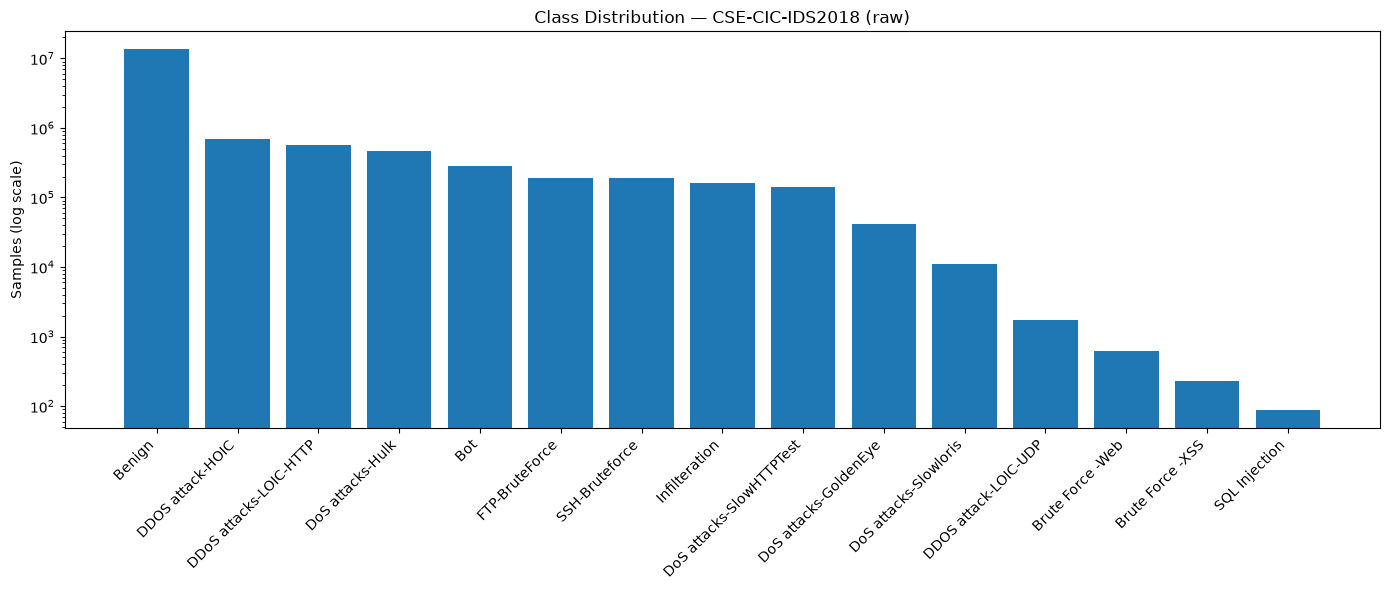

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
bars = plt.bar(label_df["Attack Type"], label_df["Count"])
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Samples (log scale)")
plt.title("Class Distribution — CSE-CIC-IDS2018 (raw)")
plt.tight_layout()
plt.savefig(IMAGES_PATH / "label_distribution_logscale.png", dpi=200)
plt.show()

## 4. Clean Each Raw File (chunked) → Parquet

One cleaning function handles everything in a single pass per chunk:
- strip column names
- drop identifier columns / duplicated header rows
- **coerce every non-label column to numeric** (`errors="coerce"`) — this also fixes the rare
  corrupted rows that used to require a separate "recovery" pass in the original notebooks
- replace `inf`/`-inf` with `NaN`
- median-impute remaining `NaN`
- drop in-chunk duplicate rows

The result is written straight to Parquet chunks.

In [28]:
def clean_chunk(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.strip()

    cols_to_drop = [c for c in DROP_COLUMNS if c in df.columns]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)

    # remove duplicated header rows
    df = df[df["Label"] != "Label"].copy()

    # force every feature column to numeric (handles corrupted/mixed-type rows)
    feature_cols = [c for c in df.columns if c not in ("Label", "Timestamp")]
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    medians = df[feature_cols].median()
    df[feature_cols] = df[feature_cols].fillna(medians).fillna(0)

    df.drop_duplicates(inplace=True)
    return df

In [29]:
processing_report = []

for file in csv_files:
    base_name = os.path.basename(file).replace(".csv", "")
    print(f"Processing {base_name} ...")

    for chunk_no, chunk in enumerate(
        tqdm(pd.read_csv(file, chunksize=CHUNK_SIZE, low_memory=False), leave=False)
    ):
        original_rows = len(chunk)
        chunk = clean_chunk(chunk)

        out_path = CLEANED_PARQUET_PATH / f"{base_name}_chunk_{chunk_no}.parquet"
        chunk.to_parquet(out_path, index=False, engine="fastparquet")

        processing_report.append({
            "File": base_name,
            "Chunk": chunk_no,
            "Original Rows": original_rows,
            "Cleaned Rows": len(chunk),
        })

        del chunk
        gc.collect()

report_df = pd.DataFrame(processing_report)
report_df.to_csv(REPORTS_PATH / "chunk_processing_report.csv", index=False)

summary = report_df.groupby("File")[["Original Rows", "Cleaned Rows"]].sum()
summary["Rows Removed"] = summary["Original Rows"] - summary["Cleaned Rows"]
summary["Removal %"] = (summary["Rows Removed"] / summary["Original Rows"] * 100).round(2)
summary

Processing 02-14-2018 ...


0it [00:00, ?it/s]

Processing 02-15-2018 ...


Processing 02-16-2018 ...


Processing 02-20-2018-002 ...


...

Processing 02-23-2018 ...


Processing 02-28-2018 ...


Processing 03-01-2018 ...


Processing 03-02-2018 ...


,Original Rows,Cleaned Rows,Rows Removed,Removal %
File,,,,
02-14-2018,1048575,823972,224603,21.42
02-15-2018,1048575,1047358,1217,0.12
02-16-2018,1048575,911878,136697,13.04
02-20-2018-002,7948748,7945638,3110,0.04
02-21-2018,1048575,1031052,17523,1.67
02-22-2018,1048575,1047703,872,0.08
02-23-2018,1048575,1047806,769,0.07
02-28-2018,613104,612749,355,0.06
03-01-2018,331125,331032,93,0.03


In [30]:
import sys, pandas, pyarrow
print("Python:", sys.version)
print("pandas:", pandas.__version__)
print("pyarrow:", pyarrow.__version__)


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas: 2.3.3
pyarrow: 25.0.0


## 5. Merge & Deduplicate (DuckDB)

DuckDB lets us scan and deduplicate across *all* cleaned Parquet chunks without loading everything
into memory at once.

In [31]:
import duckdb

con = duckdb.connect()
con.execute("PRAGMA threads=8;")
con.execute("PRAGMA memory_limit='8GB';")

FINAL_FILE = FINAL_CLEANED_PATH / "cleaned_ids2018.parquet"

con.execute(f"""
COPY (
    SELECT DISTINCT *
    FROM read_parquet('{CLEANED_PARQUET_PATH}/*.parquet')
)
TO '{FINAL_FILE}'
(FORMAT PARQUET);
""")

total_rows = con.execute(f"SELECT COUNT(*) FROM read_parquet('{FINAL_FILE}')").fetchone()[0]
print(f"Final cleaned & deduplicated rows: {total_rows:,}")

Final cleaned & deduplicated rows: 15,801,095


In [32]:
label_dist = con.execute(f"""
SELECT Label, COUNT(*) AS Count
FROM read_parquet('{FINAL_FILE}')
GROUP BY Label
ORDER BY Count DESC
""").fetchdf()

label_dist.to_csv(REPORTS_PATH / "final_label_distribution.csv", index=False)
label_dist

,Label,Count
0,Benign,13446845
1,DDOS attack-HOIC,668461
2,DDoS attacks-LOIC-HTTP,576175
3,DoS attacks-Hulk,434873
4,Bot,282310
5,Infilteration,161897
6,SSH-Bruteforce,117322
7,DoS attacks-GoldenEye,41455
8,FTP-BruteForce,39352
9,DoS attacks-SlowHTTPTest,19462


## 6. Core EDA on the Cleaned Dataset

We work on a representative sample rather than the full multi-million-row dataset for the heavier statistics (correlation, skew, outliers).

In [33]:
sample_df = con.execute(f"""
SELECT *
FROM read_parquet('{FINAL_FILE}')
USING SAMPLE 250000 ROWS (reservoir)
""").fetchdf()

numeric_df = sample_df.select_dtypes(include=np.number)
print("Sample shape:", sample_df.shape)
print("Numeric features:", numeric_df.shape[1])

Sample shape: (250000, 80)
Numeric features: 78


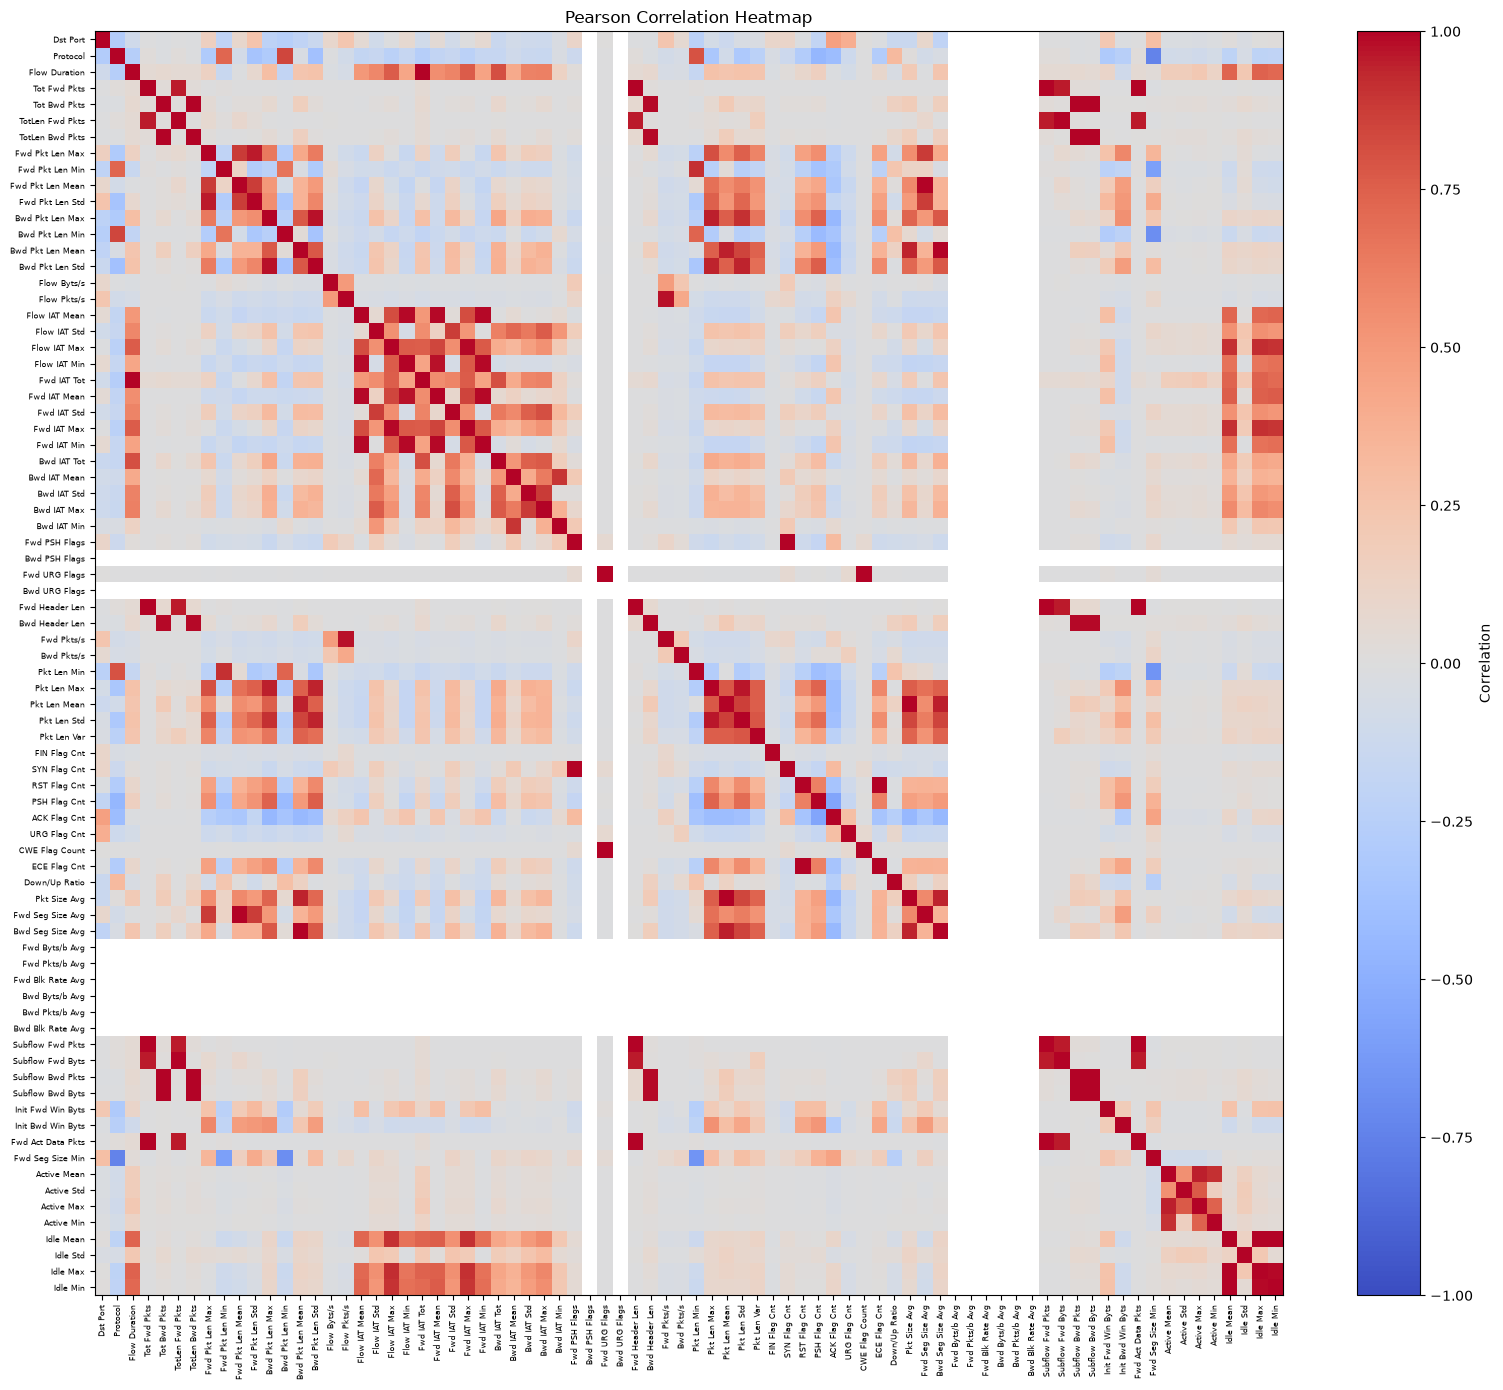

In [34]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 14))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90, fontsize=6)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, fontsize=6)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.savefig(REPORTS_PATH / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

In [35]:
threshold = 0.90
corr_abs = correlation_matrix.abs()

high_corr = [
    [corr_abs.columns[i], corr_abs.columns[j], correlation_matrix.iloc[i, j]]
    for i in range(len(corr_abs.columns))
    for j in range(i + 1, len(corr_abs.columns))
    if corr_abs.iloc[i, j] >= threshold
]

high_corr_df = pd.DataFrame(high_corr, columns=["Feature 1", "Feature 2", "Correlation"])
high_corr_df = high_corr_df.sort_values("Correlation", key=abs, ascending=False)
high_corr_df.to_csv(REPORTS_PATH / "highly_correlated_features.csv", index=False)

print(f"Highly correlated pairs (|r| >= {threshold}): {len(high_corr_df)}")
high_corr_df.head(20)

Highly correlated pairs (|r| >= 0.9): 62


,Feature 1,Feature 2,Correlation
12,TotLen Fwd Pkts,Subflow Fwd Byts,1.000000
8,Tot Bwd Pkts,Subflow Bwd Pkts,1.000000
41,Fwd PSH Flags,SYN Flag Cnt,1.000000
19,Fwd Pkt Len Mean,Fwd Seg Size Avg,1.000000
25,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.000000
42,Fwd URG Flags,CWE Flag Count,1.000000
3,Tot Fwd Pkts,Subflow Fwd Pkts,1.000000
16,TotLen Bwd Pkts,Subflow Bwd Byts,1.000000
51,RST Flag Cnt,ECE Flag Cnt,0.999987
5,Tot Fwd Pkts,Fwd Act Data Pkts,0.999608


In [36]:
distribution_metrics = pd.DataFrame({
    "Feature": numeric_df.columns,
    "Mean": numeric_df.mean(),
    "Std": numeric_df.std(),
    "Skewness": numeric_df.skew(),
    "Kurtosis": numeric_df.kurt(),
}).reset_index(drop=True)

distribution_metrics.to_csv(REPORTS_PATH / "distribution_summary.csv", index=False)

print("Extremely skewed (|skew| > 2):", (distribution_metrics["Skewness"].abs() > 2).sum())
print("Heavy-tailed (kurtosis > 10)  :", (distribution_metrics["Kurtosis"] > 10).sum())
distribution_metrics.sort_values("Skewness", ascending=False).head(15)

Extremely skewed (|skew| > 2): 60
Heavy-tailed (kurtosis > 10)  : 55


,Feature,Mean,Std,Skewness,Kurtosis
52,Down/Up Ratio,0.485540,0.940006,126.029362,27268.127770
43,Pkt Len Var,42138.926537,97667.831435,108.619497,32074.607072
65,Subflow Bwd Byts,4571.530192,207176.786028,106.947303,14008.218012
6,TotLen Bwd Pkts,4571.550404,207178.726762,106.946995,14008.038439
36,Bwd Header Len,131.891248,2827.223746,106.503707,14128.508821
64,Subflow Bwd Pkts,6.272184,144.551965,105.348270,13612.664389
4,Tot Bwd Pkts,6.272184,144.551965,105.348270,13612.664389
5,TotLen Fwd Pkts,1231.165852,59982.757802,76.540038,6427.463138
63,Subflow Fwd Byts,1231.165852,59982.757802,76.540038,6427.463138
50,CWE Flag Count,0.000180,0.013415,74.515920,5550.666772


In [37]:
outlier_rows = []
for feature in numeric_df.columns:
    Q1, Q3 = numeric_df[feature].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    count = ((numeric_df[feature] < lower) | (numeric_df[feature] > upper)).sum()
    outlier_rows.append({
        "Feature": feature,
        "Outlier Count": int(count),
        "Outlier %": round(count / len(numeric_df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values("Outlier %", ascending=False).reset_index(drop=True)
outlier_df.to_csv(REPORTS_PATH / "outlier_summary.csv", index=False)

print("Features with >20% outliers:", (outlier_df["Outlier %"] > 20).sum())
outlier_df.head(15)

Features with >20% outliers: 6


,Feature,Outlier Count,Outlier %
0,Bwd IAT Max,58815,23.53
1,Bwd IAT Std,58588,23.44
2,Fwd IAT Min,56548,22.62
3,Bwd IAT Min,56122,22.45
4,Flow IAT Max,54686,21.87
5,Init Bwd Win Byts,51152,20.46
6,Flow IAT Mean,49814,19.93
7,Fwd IAT Max,49602,19.84
8,Fwd IAT Mean,48426,19.37
9,ECE Flag Cnt,48235,19.29


## 7. Build the Stratified Modeling Dataset (`ml_dataset.parquet`)

Rather than training on tens of millions of raw rows, we build one class-aware sample that:
- keeps **every row** of rare/minority attack classes (nothing is thrown away)
- caps the dominant classes (e.g. `Benign`) with reservoir sampling

This single dataset (`Processed_Data/ml_dataset.parquet`) is the input to the second notebook
(CTGAN augmentation and model-ready splits).

In [38]:
TARGET_TOTAL = 1_000_000
RARE_THRESHOLD = 10_000

plan = label_dist.copy()
total_rows_all = plan["Count"].sum()

plan["Sample"] = (plan["Count"] / total_rows_all * TARGET_TOTAL).round().astype("int64")
# never throw away rare classes — keep everything below the threshold
plan.loc[plan["Count"] <= RARE_THRESHOLD, "Sample"] = plan["Count"]
plan

,Label,Count,Sample
0,Benign,13446845,851007
1,DDOS attack-HOIC,668461,42305
2,DDoS attacks-LOIC-HTTP,576175,36464
3,DoS attacks-Hulk,434873,27522
4,Bot,282310,17866
5,Infilteration,161897,10246
6,SSH-Bruteforce,117322,7425
7,DoS attacks-GoldenEye,41455,2624
8,FTP-BruteForce,39352,2490
9,DoS attacks-SlowHTTPTest,19462,1232


In [39]:
con.register("sample_plan", plan[["Label", "Sample"]])

ML_DATASET_FILE = PROCESSED_DATA_PATH / "ml_dataset.parquet"

con.execute(f"""
COPY (
    SELECT d.*
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY Label ORDER BY random()) AS rn
        FROM read_parquet('{FINAL_FILE}')
    ) d
    JOIN sample_plan p ON d.Label = p.Label
    WHERE d.rn <= p."Sample"
)
TO '{ML_DATASET_FILE}'
(FORMAT PARQUET);
""")

rows = con.execute(f"SELECT COUNT(*) FROM read_parquet('{ML_DATASET_FILE}')").fetchone()[0]
print(f"ml_dataset.parquet rows: {rows:,}")
print("Saved to:", ML_DATASET_FILE)

ml_dataset.parquet rows: 1,002,490
Saved to: M:\IDS\c_filesnew\Processed_Data\ml_dataset.parquet


In [40]:
final_check = con.execute(f"""
SELECT Label, COUNT(*) AS Count
FROM read_parquet('{ML_DATASET_FILE}')
GROUP BY Label
ORDER BY Count DESC
""").fetchdf()
final_check

,Label,Count
0,Benign,851007
1,DDOS attack-HOIC,42305
2,DDoS attacks-LOIC-HTTP,36464
3,DoS attacks-Hulk,27522
4,Bot,17866
5,Infilteration,10246
6,SSH-Bruteforce,7425
7,DoS attacks-GoldenEye,2624
8,FTP-BruteForce,2490
9,DDOS attack-LOIC-UDP,1730


---
**Next step:** open `02_CTGAN_Data_Preparation.ipynb`, which picks up from `Processed_Data/ml_dataset.parquet`.